In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from collections import Counter

print("Import xong")

Import xong


In [6]:
raw_train  = pd.read_parquet("../data/raw/train-00000-of-00001.parquet")
raw_val    = pd.read_parquet("../data/raw/validation-00000-of-00001.parquet")
raw_test   = pd.read_parquet("../data/raw/test-00000-of-00001.parquet")

In [7]:
raw_train.head()

,Unnamed: 0,title,text,label
0,0,‘Maury’ Show Official Facebook Posts F*CKED U...,Maury is perhaps one of the trashiest shows on...,0
1,1,Trump’s Favorite News Channel Tries To Soothe...,"Yesterday, after the father of one of the UCLA...",0
2,2,"Russia warns Iraq, Kurds not to destabilize Mi...",MOSCOW (Reuters) - Russia on Wednesday warned ...,1
3,3,WATCH STEVE SCALISE Throw A Strike At The Nati...,"House Majority Whip Steve Scalise (R., La.) th...",0
4,4,Trump Will HATE What Stephen Colbert Just Did...,It can be said that Late Show host Stephen Col...,0


In [3]:
train_df = pd.read_csv("../data/processed/train_clean.csv")
val_df = pd.read_csv("../data/processed/validation_clean.csv")
test_df = pd.read_csv("../data/processed/test_clean.csv")

print(f"Train : {train_df.shape}")
print(f"Val   : {val_df.shape}")
print(f"Test  : {test_df.shape}")
print(f"Total : {len(train_df) + len(val_df) + len(test_df)} mẫu")

Train : (24349, 3)
Val   : (8115, 3)
Test  : (8117, 3)
Total : 40581 mẫu


## Thông tin tổng quan

In [5]:
train_df.head()

,title,text,label
0,‘Maury’ Show Official Facebook Posts F*CKED UP...,Maury is perhaps one of the trashiest shows on...,0
1,Trump’s Favorite News Channel Tries To Soothe ...,"Yesterday, after the father of one of the UCLA...",0
2,"Russia warns Iraq, Kurds not to destabilize Mi...",MOSCOW (Reuters) - Russia on Wednesday warned ...,1
3,WATCH STEVE SCALISE Throw A Strike At The Nati...,"House Majority Whip Steve Scalise (R., La.) th...",0
4,Trump Will HATE What Stephen Colbert Just Did ...,It can be said that Late Show host Stephen Col...,0


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24349 entries, 0 to 24348
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   24349 non-null  object
 1   text    24321 non-null  object
 2   label   24349 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 570.8+ KB


In [11]:
train_df.describe()

,label
count,24349.000000
mean,0.541870
std,0.498254
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


## Kiểm tra missing value

In [12]:
print(train_df.isnull().sum())

title     0
text     28
label     0
dtype: int64


## kiểm tra độ lệch nhãn

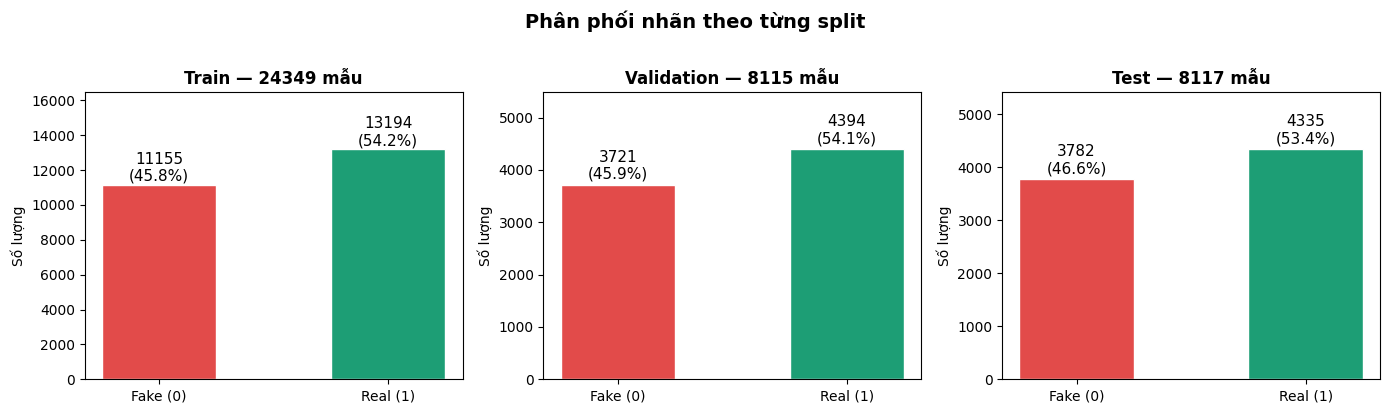

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (df, name) in zip(axes, [(train_df,'Train'),(val_df,'Validation'),(test_df,'Test')]):
    counts = df['label'].value_counts().sort_index()
    colors = ['#E24B4A', '#1D9E75']
    bars = ax.bar(['Fake (0)', 'Real (1)'], counts.values, color=colors, width=0.5, edgecolor='white')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{val}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=11)
    ax.set_title(f'{name} — {len(df)} mẫu', fontweight='bold')
    ax.set_ylabel('Số lượng')
    ax.set_ylim(0, counts.max() * 1.25)

plt.suptitle('Phân phối nhãn theo từng split', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Tính độ dài (theo từ) cho title và text
for df in [train_df, val_df, test_df]:
    df["title_len"] = df["title"].astype(str).apply(lambda x: len(x.split()))
    df["text_len"] = df["text"].astype(str).apply(lambda x: len(x.split()))

print("=== ĐỘ DÀI TITLE (từ) ===")
print(train_df.groupby('label')['title_len'].describe().round(1))
print("\n=== ĐỘ DÀI TEXT (từ) ===")
print(train_df.groupby('label')['text_len'].describe().round(1))

=== ĐỘ DÀI TITLE (từ) ===
         count  mean  std  min   25%   50%   75%   max
label                                                 
0      11155.0  14.1  4.2  1.0  12.0  14.0  16.0  53.0
1      13194.0   9.9  1.9  1.0   9.0  10.0  11.0  29.0

=== ĐỘ DÀI TEXT (từ) ===
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      11155.0  425.4  365.3  1.0  268.0  373.0  505.0  7209.0
1      13194.0  390.3  305.4  2.0  143.0  355.0  528.0  5828.0


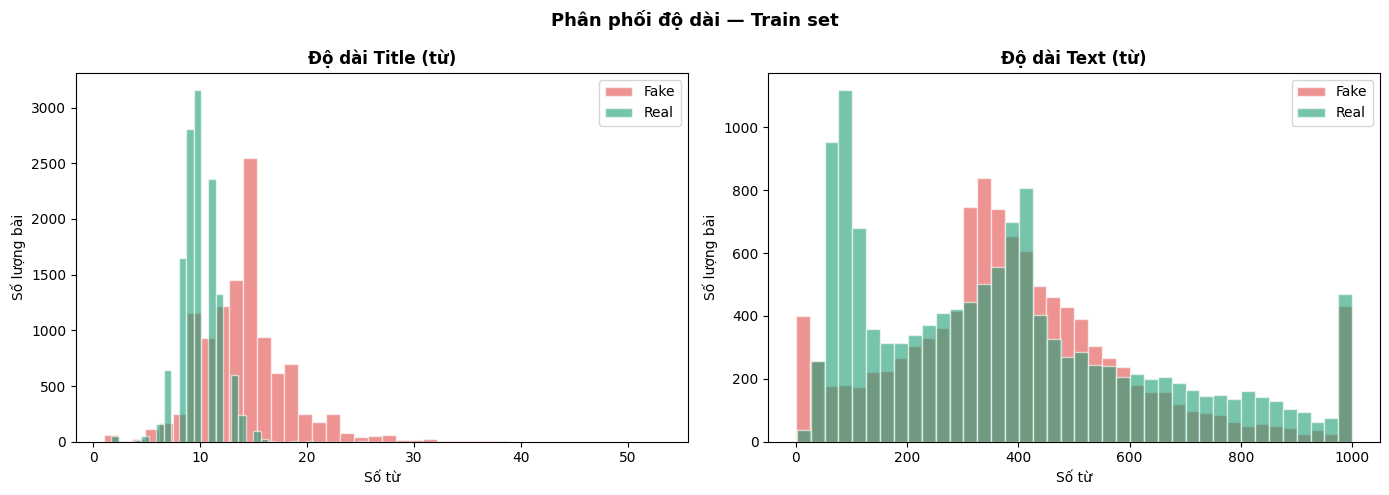

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes, ['title_len','text_len'], ['Độ dài Title (từ)','Độ dài Text (từ)']):
    for label, color, lname in [(0,'#E24B4A','Fake'),(1,'#1D9E75','Real')]:
        subset = train_df[train_df['label']==label][col]
        # cap text_len at 1000 for readability
        cap = 300 if col=='title_len' else 1000
        ax.hist(subset.clip(upper=cap), bins=40, alpha=0.6, color=color, label=lname, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Số từ')
    ax.set_ylabel('Số lượng bài')
    ax.legend()

plt.suptitle('Phân phối độ dài — Train set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

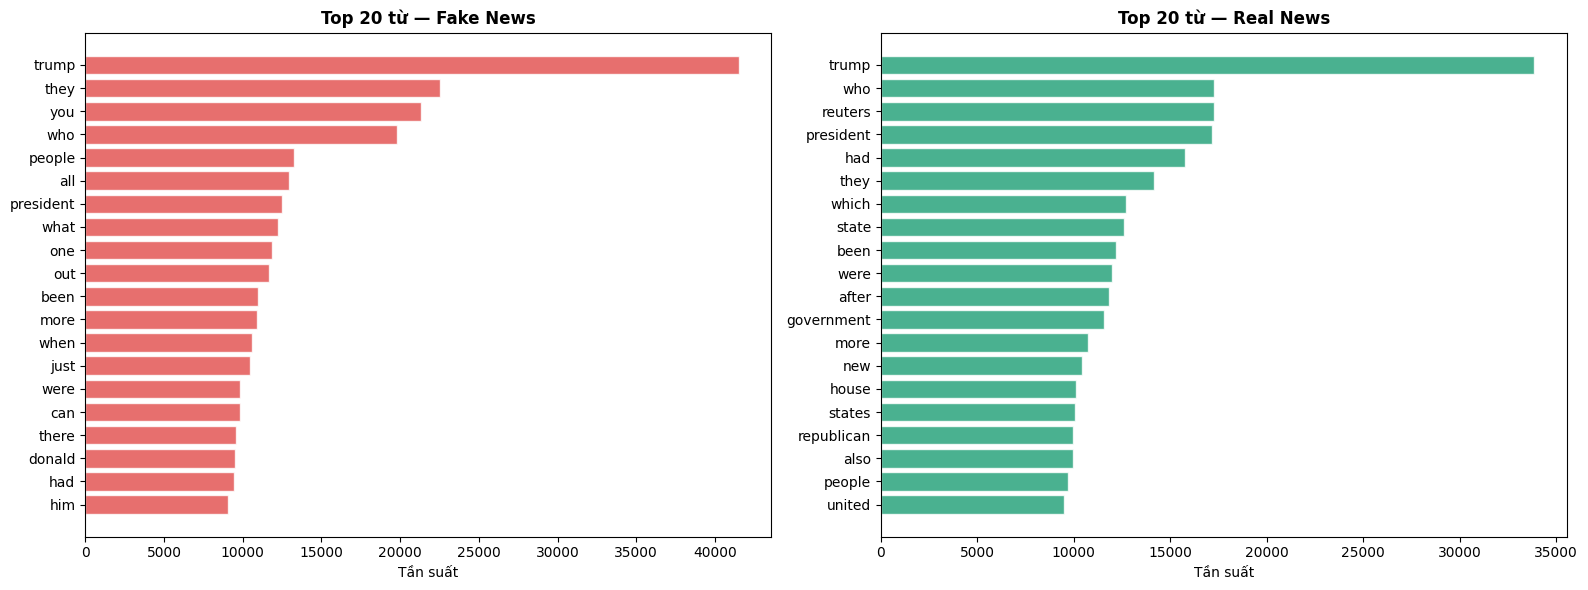

In [16]:
STOPWORDS = set(['the','a','an','is','in','of','to','and','for','on','at',
                 'it','that','this','was','with','be','are','as','from',
                 'has','have','he','she','by','not','or','but','we','our',
                 'his','her','their','its','about','said','says','will','would'])

def get_top_words(df, label, col='text', n=20):
    texts = df[df['label']==label][col].astype(str).str.lower()
    words = []
    for t in texts:
        words.extend([w for w in re.findall(r'\b[a-z]{3,}\b', t) if w not in STOPWORDS])
    return Counter(words).most_common(n)

fake_words = get_top_words(train_df, 0)
real_words = get_top_words(train_df, 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, words, color, title in zip(axes,
    [fake_words, real_words], ['#E24B4A','#1D9E75'], ['Top 20 từ — Fake News','Top 20 từ — Real News']):
    words_sorted = sorted(words, key=lambda x: x[1])
    ax.barh([w[0] for w in words_sorted], [w[1] for w in words_sorted],
            color=color, alpha=0.8, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Tần suất')

plt.tight_layout()
plt.show()

Metric                              Train   Validation         Test
Số dòng (raw)                     24,353       8,117       8,117
Số dòng (clean)                   24,349       8,115       8,117
Dòng bị loại                           4           2           0
Null values (raw)                      0           0           0
Null values (clean)                   28          12          10
Duplicates (raw)                       0           0           0
Duplicates (clean)                     0           0           0
Word count mean (raw)              418.3       421.2       422.8
Word count mean (cln)              418.2       421.2       422.6
Word count max (raw)               7,221       5,804       8,148
Word count max (cln)               7,221       5,804       8,148
% Fake label (raw)                 45.82       45.87       46.59
% Fake label (clean)               45.81       45.85       46.59


C:\Users\khanh\AppData\Local\Temp\ipykernel_8032\2862673217.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


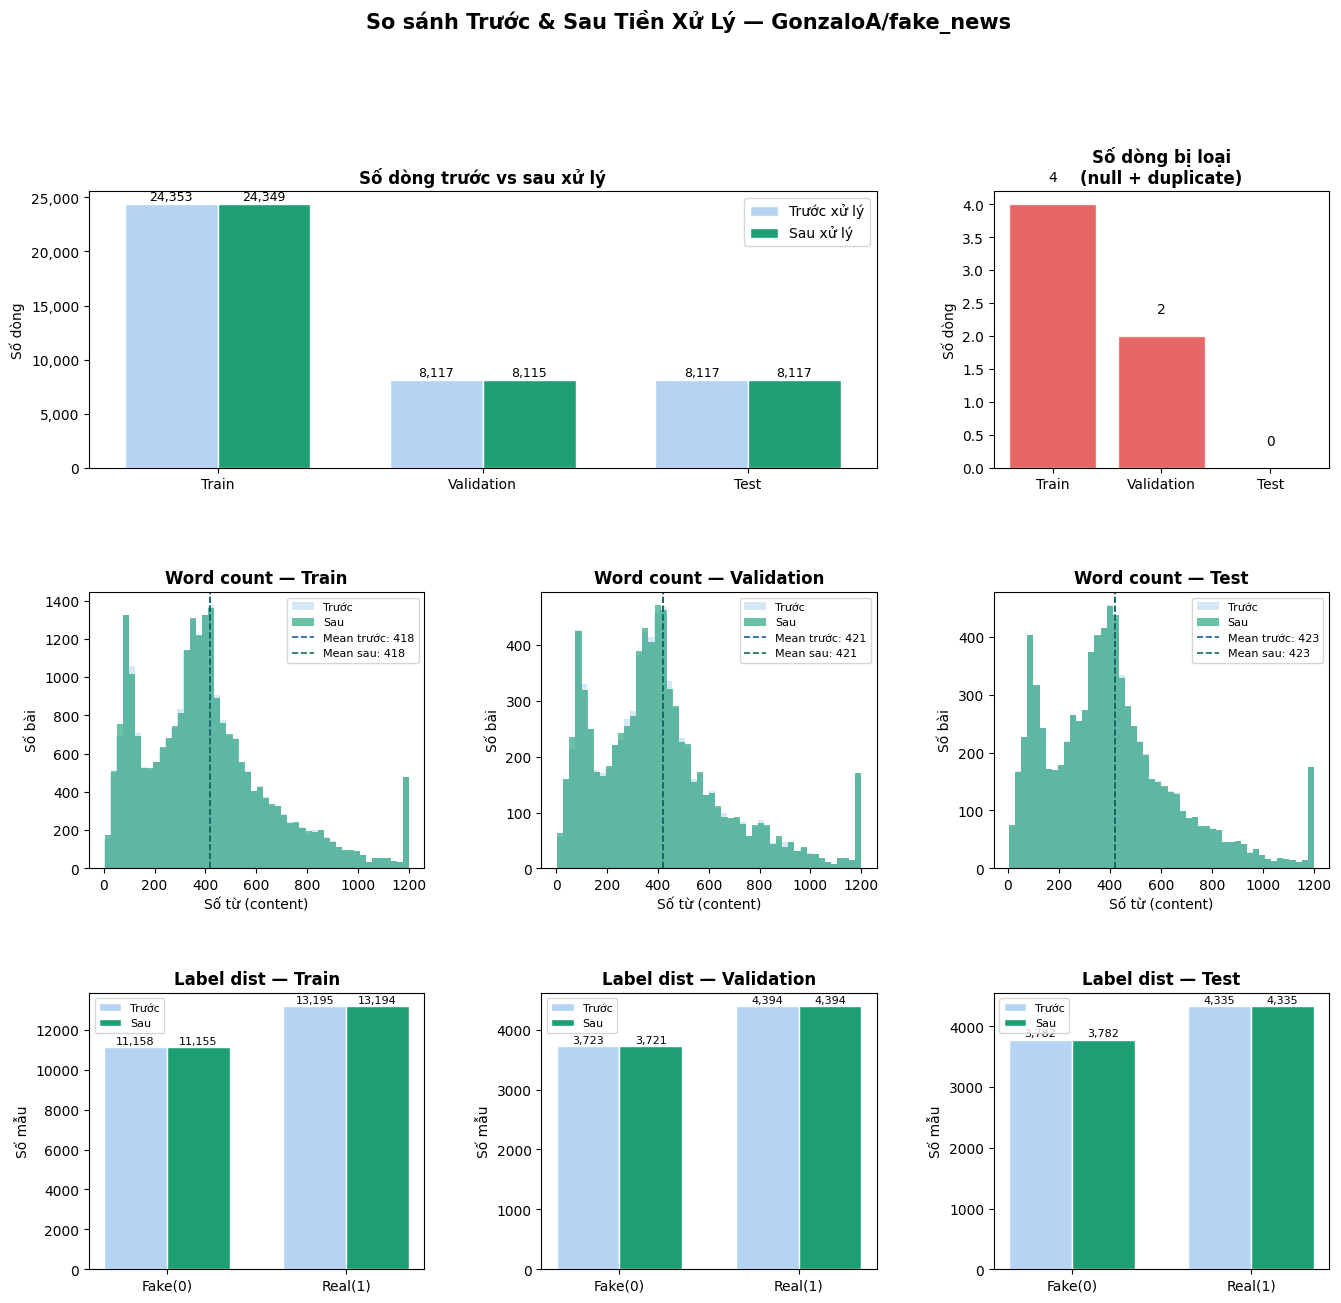


VÍ DỤ TRỰC QUAN: 1 DÒNG TRƯỚC vs SAU XỬ LÝ

[TRƯỚC] title : ' ‘Maury’ Show Official Facebook Posts F*CKED UP Caption On Guest That Looks Like Ted Cruz (IMAGE)'
[TRƯỚC] text  : 'Maury is perhaps one of the trashiest shows on television today. It s right in line with the likes of the gutter trash that is Jerry Springer, and the fact that those shows are still on the air with t'
[TRƯỚC] label : 0

[SAU]   title  : '‘Maury’ Show Official Facebook Posts F*CKED UP Caption On Guest That Looks Like Ted Cruz (IMAGE)'
[SAU]   text   : 'Maury is perhaps one of the trashiest shows on television today. It s right in line with the likes of the gutter trash that is Jerry Springer, and the fact that those shows are still on the air with t'
[SAU]   content: '‘Maury’ Show Official Facebook Posts F*CKED UP Caption On Guest That Looks Like Ted Cruz (IMAGE) Maury is perhaps one of the trashiest shows on television today. It s right in line with the likes of the gutter trash that is Jerry Springer, and the

In [20]:
# ── 1. Load raw và clean ──────────────────────────────────────────
cln_train  = pd.read_csv("../data/processed/train_clean.csv")
cln_val    = pd.read_csv("../data/processed/validation_clean.csv")
cln_test   = pd.read_csv("../data/processed/test_clean.csv")

# ── 2. Hàm đếm word count (dùng title+text ghép cho raw) ─────────
def word_count(series):
    return series.astype(str).apply(lambda x: len(x.split()))

def null_count(df, cols):
    return sum(df[c].isna().sum() for c in cols if c in df.columns)

def dup_count(df, col):
    return df.duplicated(subset=[col]).sum()

# ── 3. Tính metrics cho từng split ───────────────────────────────
results = []
for split, raw, cln in [("Train", raw_train, cln_train),
                        ("Validation", raw_val, cln_val),
                        ("Test", raw_test, cln_test)]:

    # Raw: ghép title + text
    raw_content = (raw["title"].astype(str) + " " + raw["text"].astype(str)).str.strip()
    raw_content = raw_content.apply(lambda x: re.sub(r"\s+", " ", x))
    
    # Clean: tạo lại cột content (vì file CSV chỉ lưu title và text)
    cln["content"] = (cln["title"].fillna("").astype(str) + " " + cln["text"].fillna("").astype(str)).str.strip()

    raw_wc = word_count(raw_content)
    cln_wc = word_count(cln["content"])

    results.append({
        "split"        : split,
        "raw_rows"     : len(raw),
        "cln_rows"     : len(cln),
        "removed_rows" : len(raw) - len(cln),
        "raw_nulls"    : null_count(raw, ["title","text","label"]),
        "cln_nulls"    : null_count(cln, ["title","text","content","label"]),
        "raw_dups"     : dup_count(raw, "text"),
        "cln_dups"     : dup_count(cln, "content"),
        "raw_wc_mean"  : raw_wc.mean(),
        "cln_wc_mean"  : cln_wc.mean(),
        "raw_wc_max"   : raw_wc.max(),
        "cln_wc_max"   : cln_wc.max(),
        "raw_fake_pct" : (raw["label"]==0).mean()*100,
        "cln_fake_pct" : (cln["label"]==0).mean()*100,
        "raw_wc"       : raw_wc,
        "cln_wc"       : cln_wc,
    })

# ── 4. Bảng tóm tắt text ─────────────────────────────────────────
print("=" * 68)
print(f"{'Metric':<28} {'Train':>12} {'Validation':>12} {'Test':>12}")
print("=" * 68)

metrics = [
    ("Số dòng (raw)",       "raw_rows",       "d"),
    ("Số dòng (clean)",     "cln_rows",       "d"),
    ("Dòng bị loại",        "removed_rows",   "d"),
    ("Null values (raw)",   "raw_nulls",      "d"),
    ("Null values (clean)", "cln_nulls",      "d"),
    ("Duplicates (raw)",    "raw_dups",       "d"),
    ("Duplicates (clean)",  "cln_dups",       "d"),
    ("Word count mean (raw)","raw_wc_mean",   ".1f"),
    ("Word count mean (cln)","cln_wc_mean",   ".1f"),
    ("Word count max (raw)", "raw_wc_max",    "d"),
    ("Word count max (cln)", "cln_wc_max",    "d"),
    ("% Fake label (raw)",   "raw_fake_pct",  ".2f"),
    ("% Fake label (clean)", "cln_fake_pct",  ".2f"),
]

for label, key, fmt in metrics:
    vals = [r[key] for r in results]
    if fmt == "d":
        row = f"{label:<28}" + "".join(f"{int(v):>12,}" for v in vals)
    else:
        row = f"{label:<28}" + "".join(f"{v:>12.{fmt[-2]}f}" if 'f' in fmt else f"{v:>12}" for v in vals)
    print(row)

print("=" * 68)

# ── 5. Visualize ──────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle("So sánh Trước & Sau Tiền Xử Lý — GonzaloA/fake_news",
            fontsize=15, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

colors_before = "#B5D4F4"
colors_after  = "#1D9E75"
splits = ["Train", "Validation", "Test"]

# ── 5a. Số dòng trước vs sau (grouped bar) ───────────────────────
ax0 = fig.add_subplot(gs[0, :2])
x = np.arange(3)
w = 0.35
raw_rows = [r["raw_rows"]  for r in results]
cln_rows = [r["cln_rows"]  for r in results]
b1 = ax0.bar(x - w/2, raw_rows, w, label="Trước xử lý", color=colors_before, edgecolor="white")
b2 = ax0.bar(x + w/2, cln_rows, w, label="Sau xử lý",   color=colors_after,  edgecolor="white")
for bar in list(b1) + list(b2):
    ax0.text(bar.get_x()+bar.get_width()/2, bar.get_height()+80,
            f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=9)
ax0.set_xticks(x); ax0.set_xticklabels(splits)
ax0.set_title("Số dòng trước vs sau xử lý", fontweight="bold")
ax0.set_ylabel("Số dòng"); ax0.legend()
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{int(v):,}"))

# ── 5b. Dòng bị loại ─────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 2])
removed = [r["removed_rows"] for r in results]
bars = ax1.bar(splits, removed, color="#E24B4A", edgecolor="white", alpha=0.85)
for bar, v in zip(bars, removed):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            str(v), ha="center", va="bottom", fontsize=10)
ax1.set_title("Số dòng bị loại\n(null + duplicate)", fontweight="bold")
ax1.set_ylabel("Số dòng")

# ── 5c–5e. Histogram word count trước vs sau (3 split) ───────────
for i, r in enumerate(results):
    ax = fig.add_subplot(gs[1, i])
    cap = 1200
    ax.hist(r["raw_wc"].clip(upper=cap), bins=50, alpha=0.55,
            color=colors_before, label="Trước", edgecolor="none")
    ax.hist(r["cln_wc"].clip(upper=cap), bins=50, alpha=0.65,
            color=colors_after,  label="Sau",   edgecolor="none")
    ax.axvline(r["raw_wc_mean"], color="#185FA5", linestyle="--", linewidth=1.2,
            label=f"Mean trước: {r['raw_wc_mean']:.0f}")
    ax.axvline(r["cln_wc_mean"], color="#0F6E56", linestyle="--", linewidth=1.2,
            label=f"Mean sau: {r['cln_wc_mean']:.0f}")
    ax.set_title(f"Word count — {r['split']}", fontweight="bold")
    ax.set_xlabel("Số từ (content)"); ax.set_ylabel("Số bài")
    ax.legend(fontsize=8)

# ── 5f–5h. Label distribution trước vs sau ───────────────────────
for i, r in enumerate(results):
    ax = fig.add_subplot(gs[2, i])
    raw_split = [raw_train, raw_val, raw_test][i]
    cln_split = [cln_train, cln_val, cln_test][i]

    raw_f = (raw_split["label"]==0).sum()
    raw_r = (raw_split["label"]==1).sum()
    cln_f = (cln_split["label"]==0).sum()
    cln_r = (cln_split["label"]==1).sum()

    x = np.arange(2)
    w = 0.35
    b1 = ax.bar(x - w/2, [raw_f, raw_r], w, label="Trước", color=colors_before, edgecolor="white")
    b2 = ax.bar(x + w/2, [cln_f, cln_r], w, label="Sau",   color=colors_after,  edgecolor="white")
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                f"{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Fake(0)","Real(1)"])
    ax.set_title(f"Label dist — {r['split']}", fontweight="bold")
    ax.set_ylabel("Số mẫu"); ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── 6. In ví dụ trực quan một dòng trước vs sau ──────────────────
print("\n" + "="*68)
print("VÍ DỤ TRỰC QUAN: 1 DÒNG TRƯỚC vs SAU XỬ LÝ")
print("="*68)

sample_raw = raw_train.iloc[0]
sample_cln = cln_train.iloc[0]

print("\n[TRƯỚC] title :", repr(sample_raw["title"])[:120])
print("[TRƯỚC] text  :", repr(str(sample_raw["text"])[:200]))
print("[TRƯỚC] label :", sample_raw["label"])

print("\n[SAU]   title  :", repr(sample_cln["title"])[:120])
print("[SAU]   text   :", repr(str(sample_cln["text"])[:200]))
print("[SAU]   content:", repr(str(sample_cln["content"])[:300]))
print("[SAU]   label  :", sample_cln["label"])
print("="*68)

In [ ]:
print("="*55)
print("         TỔNG KẾT EDA — GonzaloA/fake_news")
print("="*55)

total = len(train_df) + len(val_df) + len(test_df)
for df, name in [(train_df,'Train'),(val_df,'Validation'),(test_df,'Test')]:
    fake_pct = (df['label']==0).mean()*100
    real_pct = (df['label']==1).mean()*100
    print(f"\n[{name}] {len(df)} mẫu")
    print(f"  Fake: {(df['label']==0).sum()} ({fake_pct:.1f}%)  |  Real: {(df['label']==1).sum()} ({real_pct:.1f}%)")
    print(f"  Title length (mean): {df['title_len'].mean():.0f} từ")
    print(f"  Text  length (mean): {df['text_len'].mean():.0f} từ  |  max: {df['text_len'].max()} từ")

print(f"\nTổng toàn bộ dataset: {total} mẫu")
print("="*55)

         TỔNG KẾT EDA — GonzaloA/fake_news

[Train] 24259 mẫu
  Fake: 11113 (45.8%)  |  Real: 13146 (54.2%)
  Title length (mean): 12 từ
  Text  length (mean): 406 từ  |  max: 7209 từ

[Validation] 8084 mẫu
  Fake: 3709 (45.9%)  |  Real: 4375 (54.1%)
  Title length (mean): 12 từ
  Text  length (mean): 408 từ  |  max: 5797 từ

[Test] 8088 mẫu
  Fake: 3767 (46.6%)  |  Real: 4321 (53.4%)
  Title length (mean): 12 từ
  Text  length (mean): 409 từ  |  max: 8135 từ

Tổng toàn bộ dataset: 40431 mẫu
